In [91]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

def get_df(lung_real,lung_fake):
    output_list = []
    for item in lung_real:
        for phase_index in range(len(item)):
            output_list.append(["Real",phase_index]+[item[phase_index]])
    for item in lung_fake:
        for phase_index in range(len(item)):
            output_list.append(["Fake",phase_index]+[item[phase_index]])
    df=pd.DataFrame(output_list,columns=['label','phase', 'volume(%)'])
    return(df)

def get_percent(list):
    pass_check = True
    first = list[-1]
    output = [0]
    for item in list:
        if np.mean(first - item)<0:
            pass_check = False
            output.append((first-item)/first*100)
        else:
            output.append((first-item)/first*100)
            
    return [pass_check,output]

In [92]:
right_fake = np.load("/home/zhaosheng/paper4/ipynb/right_lung_fake_all_256.npy",allow_pickle=True)
right_real = np.load("/home/zhaosheng/paper4/ipynb/right_lung_real_all_256.npy",allow_pickle=True)
left_fake = np.load("/home/zhaosheng/paper4/ipynb/left_lung_fake_all_256.npy",allow_pickle=True)
left_real = np.load("/home/zhaosheng/paper4/ipynb/left_lung_real_all_256.npy",allow_pickle=True)
lung_real = left_real+right_real
lung_fake = left_fake+right_fake
total = 0
result = {}
result["left_real"] = []
result["left_fake"] = []
result["right_real"] = []
result["right_fake"] = []
result["lung_real"] = []
result["lung_fake"] = []
exclude_patients = ["165251","222538","260829","277218"]
for index,item in enumerate(right_fake):
    if right_fake[index][0] in exclude_patients:
        continue
    if len(item) == 10:
        right_fake_item = get_percent(right_fake[index][1:])
        right_real_item = get_percent(right_real[index][1:])
        left_fake_item = get_percent(left_fake[index][1:])
        left_real_item = get_percent(left_real[index][1:])
        if left_real_item[0] and right_real_item[0]:# and left_fake_item[0] and right_fake_item[0]:
            result["right_fake"].append(right_fake_item[1])
            result["right_real"].append(right_real_item[1])
            result["left_fake"].append(left_fake_item[1])
            result["left_real"].append(left_real_item[1])
        # result["left_fake"].append(get_percent(left_fake[index][1:]))
        # result["left_real"].append(get_percent(left_real[index][1:]))
        # result["right_real"].append(get_percent(right_real[index][1:]))
        # result["lung_real"].append(get_percent(np.array(left_real[index][1:])+np.array(right_real[index][1:])))
            result["lung_fake"].append(get_percent(np.array(left_fake[index][1:])+np.array(right_fake[index][1:]))[1])
            result["lung_real"].append(get_percent(np.array(left_real[index][1:])+np.array(right_real[index][1:]))[1])
        else:
            continue
        total+=1
    # if total==20:
    #     break
print(total)
left_real = np.array(result['left_real'])
left_fake = np.array(result['left_fake'])
right_real = np.array(result['right_real'])
right_fake = np.array(result['right_fake'])
lung_real = np.array(result['lung_real'])
lung_fake = np.array(result['lung_fake'])

193


In [93]:
def plotMeanLungVolumeChange(left_real,left_fake,title="Left Lung"):
    x = np.arange(len(left_real[0]))
    radio = 1
    std_real = np.std(left_real,axis=0)*radio
    mean_real = np.mean(left_real,axis=0)
    mean_fake = np.mean(left_fake,axis=0)
    std_fake = np.std(left_fake,axis=0)*radio
    plt.figure(dpi=200)
    

    plt.fill_between(x, mean_real-std_real,mean_real+std_real, alpha=0.2,label="Real CT") 
    plt.fill_between(x, mean_fake-std_fake,mean_fake+std_fake, alpha=0.2,label="sCT")
   
    plt.plot(x,mean_real,label="Real CT")#,color='red')
    plt.plot(x,mean_fake,label="sCT")#,color="blue")
    plt.legend()
    plt.title(title)
    plt.ylabel("Lung Volume(%)")
    plt.xlabel("Phase")
    plt.xticks([0,1,2,3,4,5,6,7,8,9],["t0","t1","t2","t3","t4","t5","t6","t7","t8","t9"])
    plt.yticks([-30,-20,-10,0,10,20,30])
    plt.show()

def plotLungVolumeChange(real,fake,prefix="Left Lung"):
    x = np.arange(len(left_real[0]))
    plt.plot(x,real,label="real ct")
    plt.plot(x,fake,label="sct")
    plt.legend()
    plt.title('Left Lung Volume change')
    plt.ylabel("Lung Volume(%)")
    plt.xlabel("Phase")
    plt.show()


In [94]:
def plot_volume(lung_real,lung_fake):
    x = np.arange(len(left_real[0]))
    radio = 1
    std_real = np.std(lung_real,axis=0)*radio
    mean_real = np.mean(lung_real,axis=0)
    mean_fake = np.mean(lung_fake,axis=0)
    std_fake = np.std(lung_fake,axis=0)*radio
    plt.figure(dpi=200)
    plt.fill_between(x, mean_real-std_real,mean_real+std_real, alpha=0.2,label="Real std") 
    plt.fill_between(x, mean_fake-std_fake,mean_fake+std_fake, alpha=0.2,label="Fake std")
    plt.plot(x,mean_real,label="Real Mean")#,color='red')
    plt.plot(x,mean_fake,label="Fake Mean")#,color="blue")
    df = get_df(lung_real,lung_fake)
    sns.boxplot(
        x="phase",
        y="volume(%)", 
        data=df,
        hue="label",  # 引入参数
        fliersize=0,
        whis=1.2,
        showfliers = False
    )
    plt.legend()
    plt.ylabel("Lung Volume(%)")
    plt.xlabel("Phase")
    plt.xticks([0,1,2,3,4,5,6,7,8,9],["t0","t1","t2","t3","t4","t5","t6","t7","t8","t9"])
    plt.yticks([0,5,10,15,20,25,30])
    plt.show()

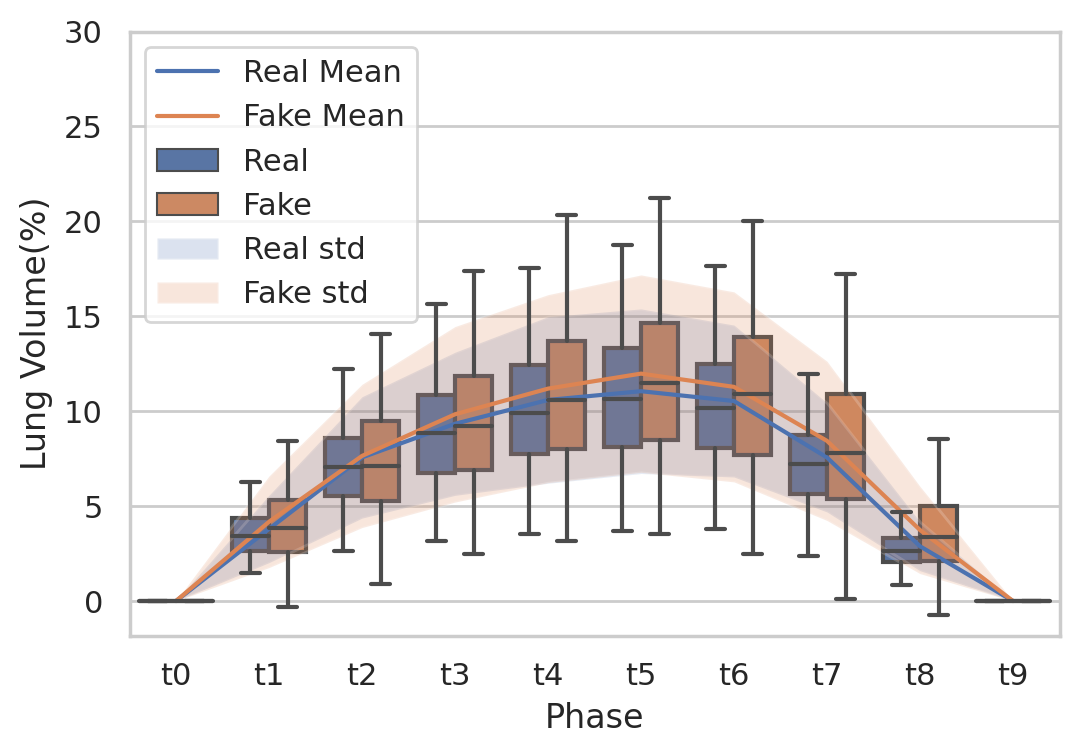

In [95]:
plot_volume(lung_real,lung_fake)

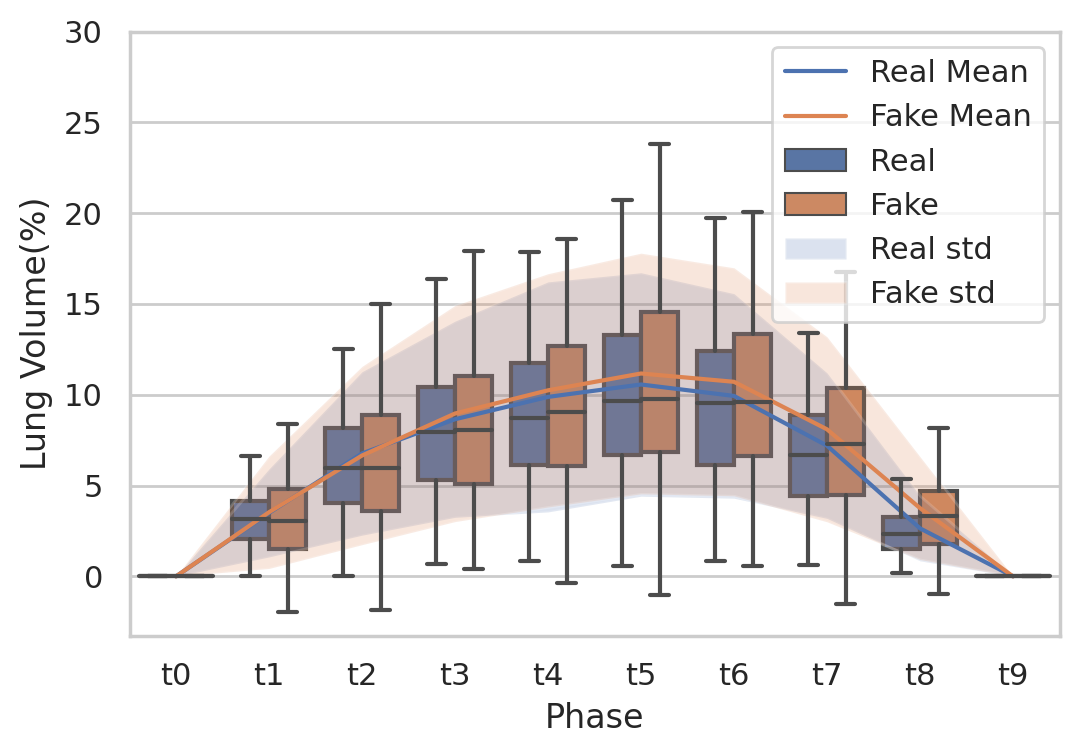

In [97]:
plot_volume(left_real,left_fake)

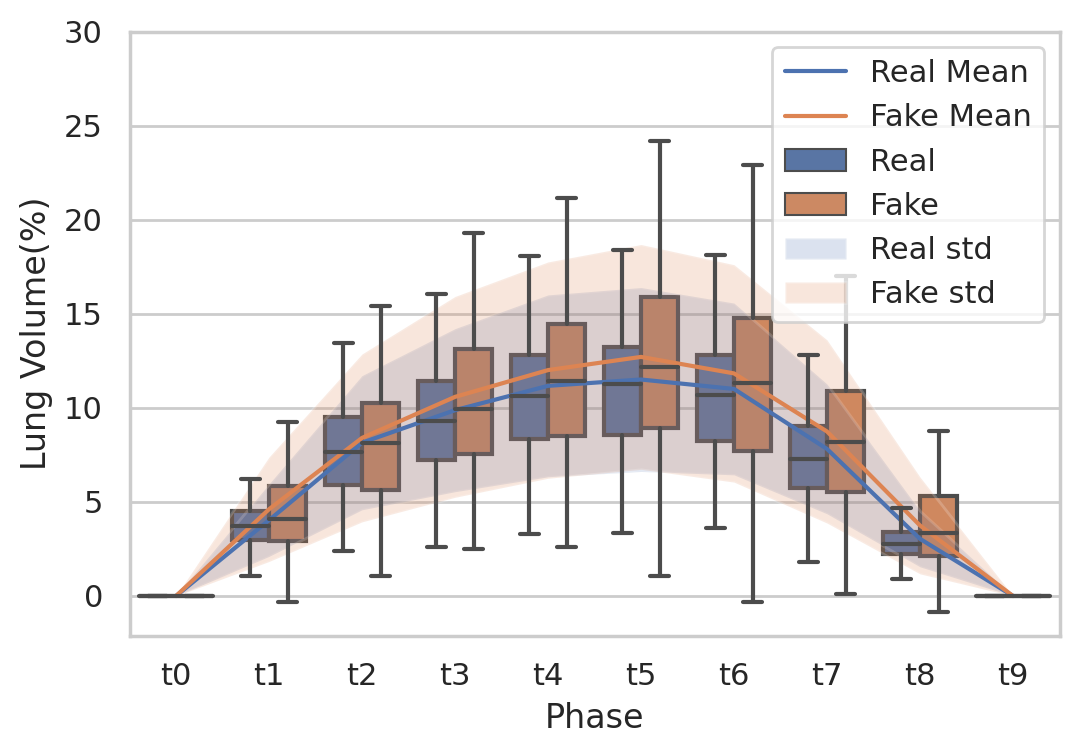

In [98]:
plot_volume(right_real,right_fake)

In [88]:
mean_real

array([ 0.        ,  3.79641907,  7.56318659,  9.33546964, 10.59085862,
       11.05161651, 10.53445347,  7.56113009,  2.88232736,  0.        ])

In [89]:
mean_fake

array([ 0.        ,  4.17375981,  7.64190484,  9.83572673, 11.18698789,
       11.97809642, 11.28010631,  8.43549948,  3.73949472,  0.        ])

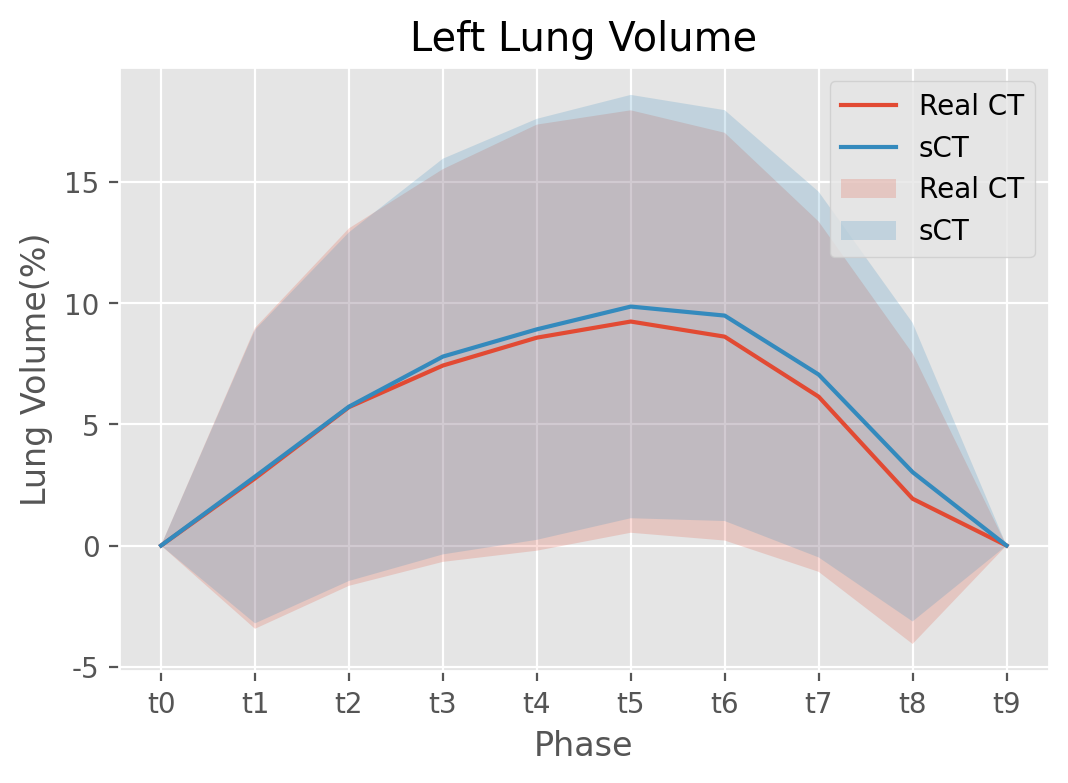

In [4]:
plotMeanLungVolumeChange(left_real,left_fake,"Left Lung Volume")

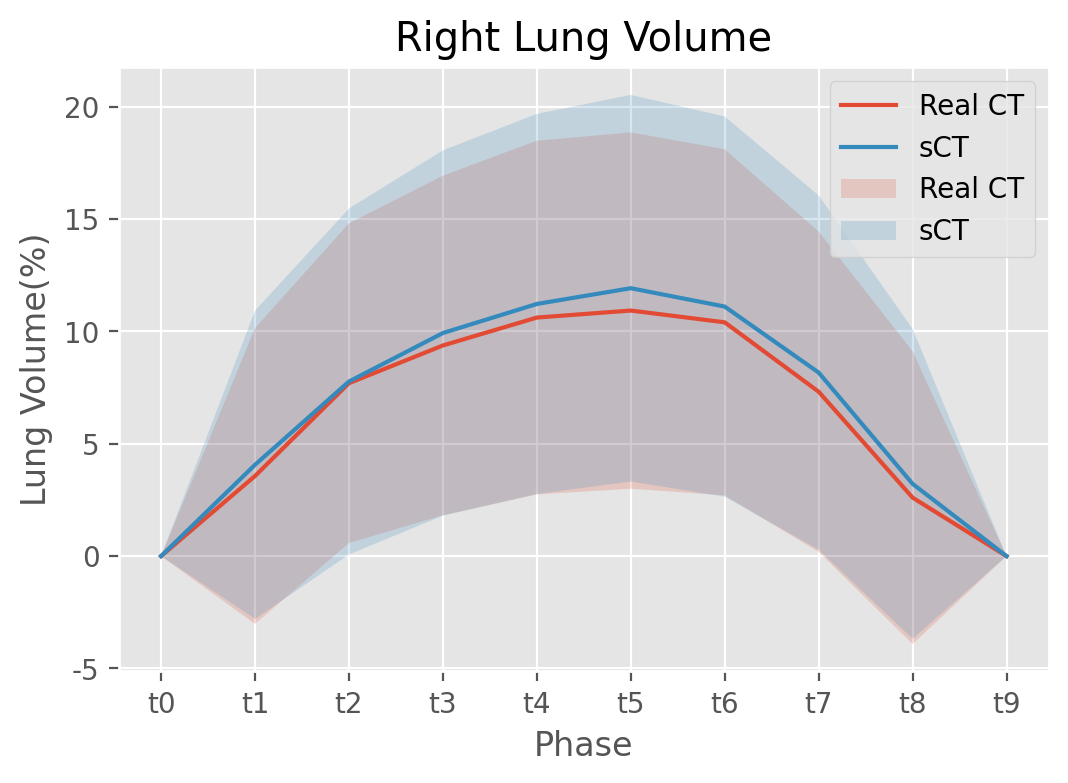

In [5]:
plotMeanLungVolumeChange(right_real,right_fake,"Right Lung Volume")

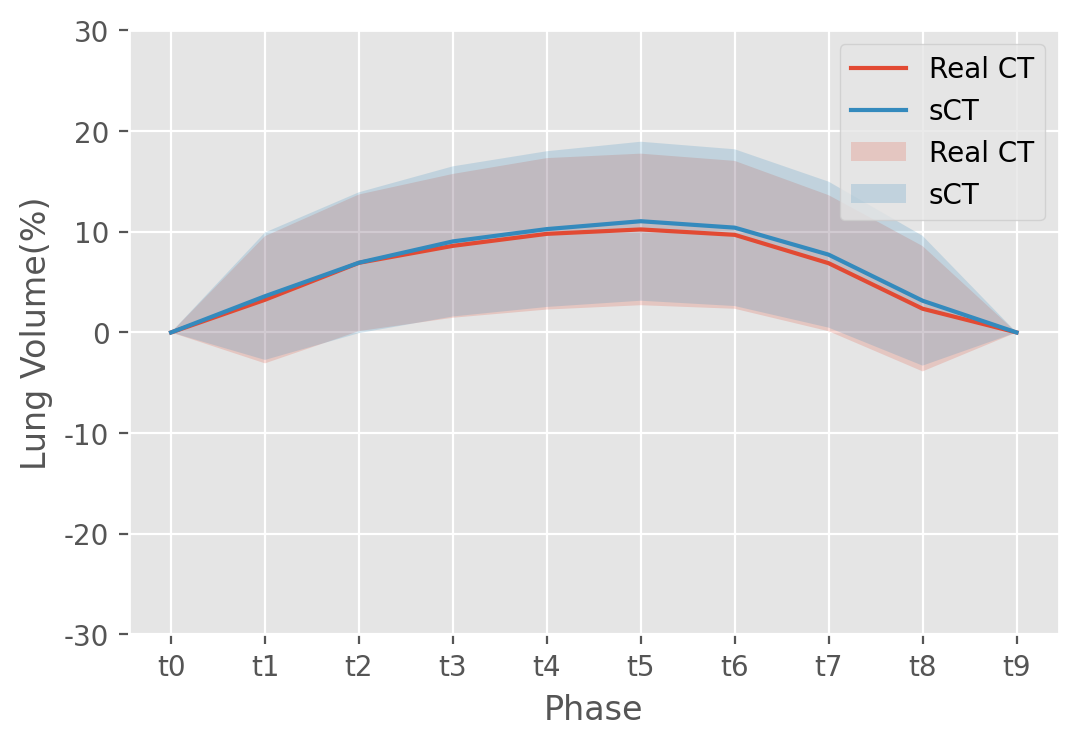

In [10]:
plotMeanLungVolumeChange(lung_real,lung_fake,"")

0.0


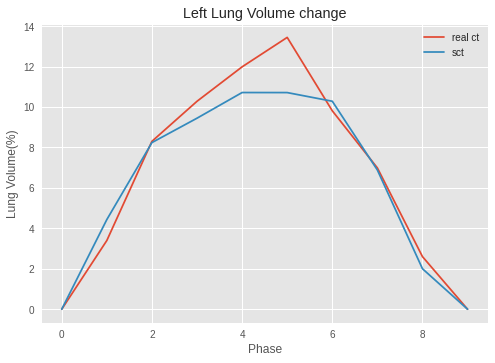

0.0


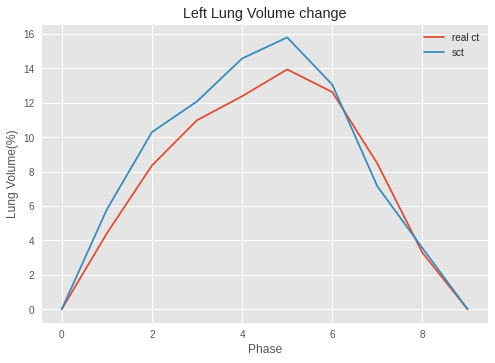

0.0


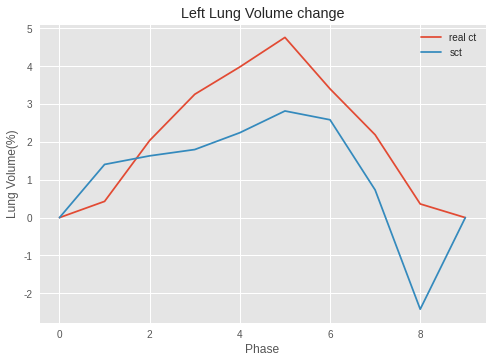

0.0


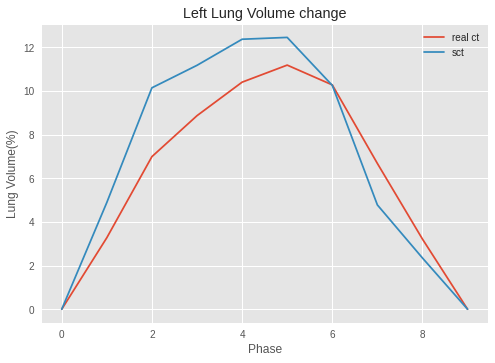

0.0


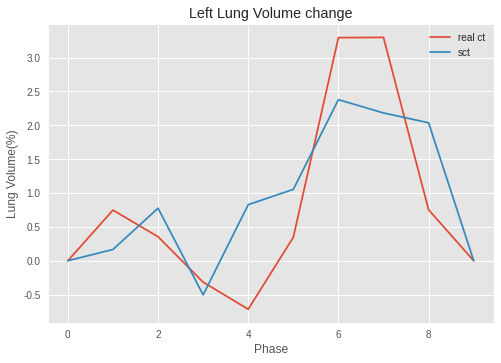

0.0


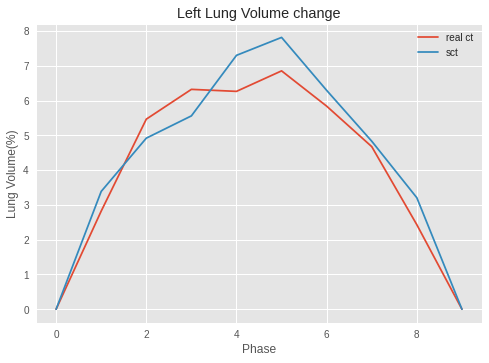

0.0


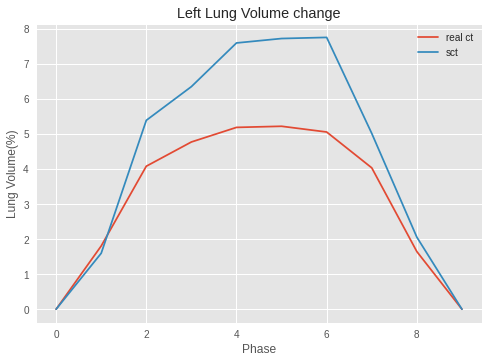

0.0


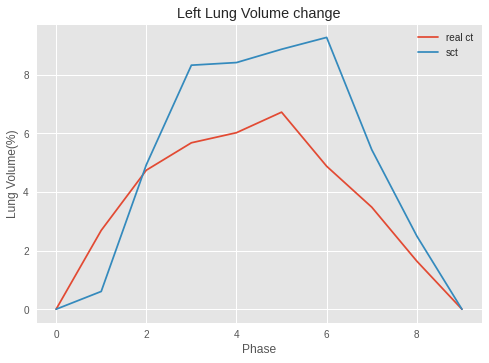

0.0


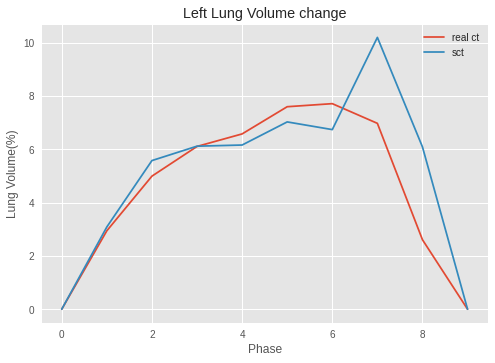

0.0


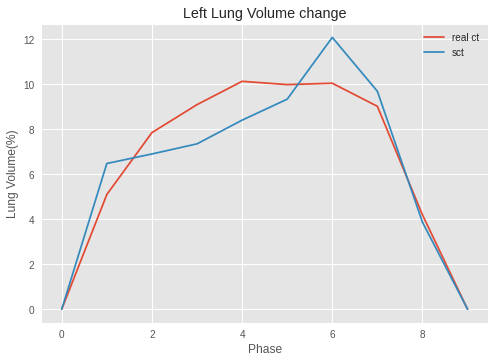

0.0


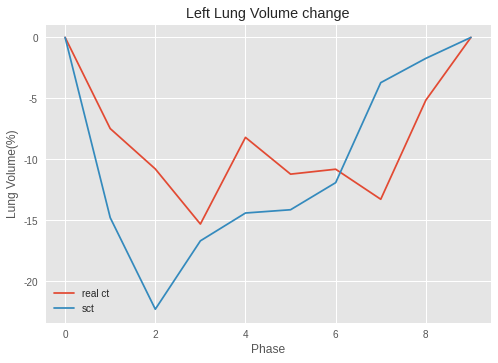

0.0


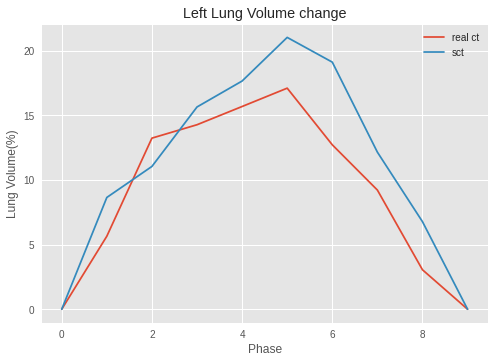

0.0


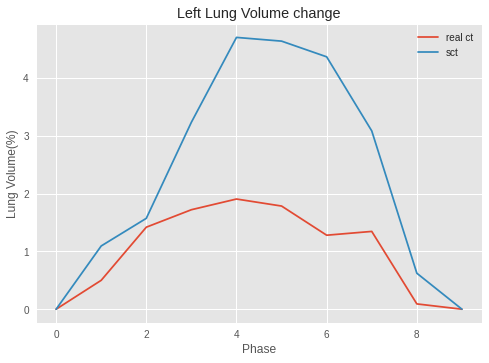

0.0


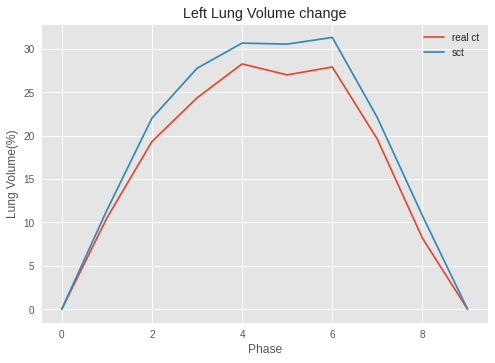

0.0


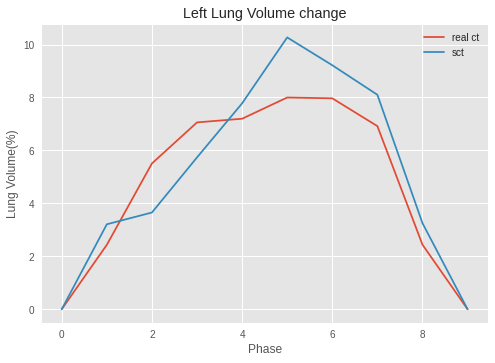

0.0


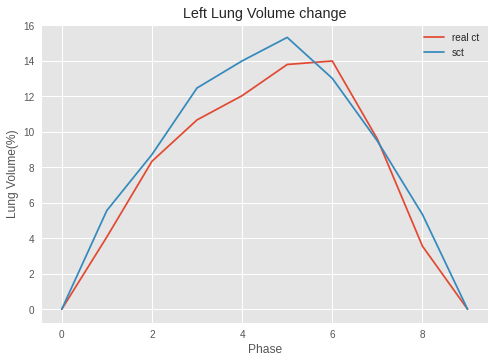

0.0


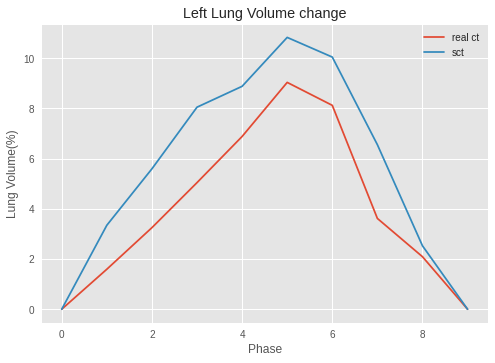

0.0


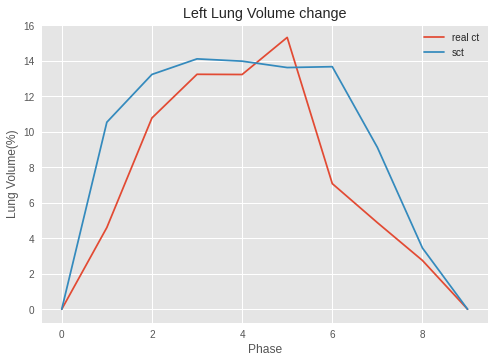

0.0


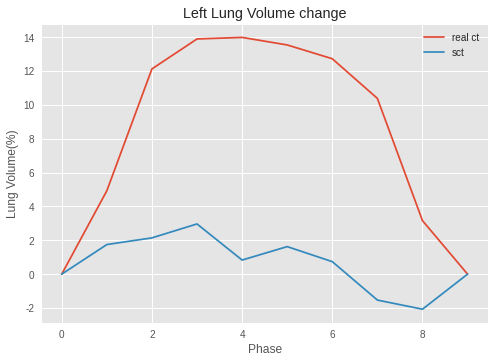

0.0


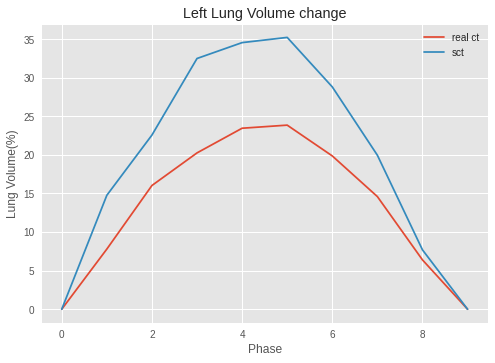

0.0


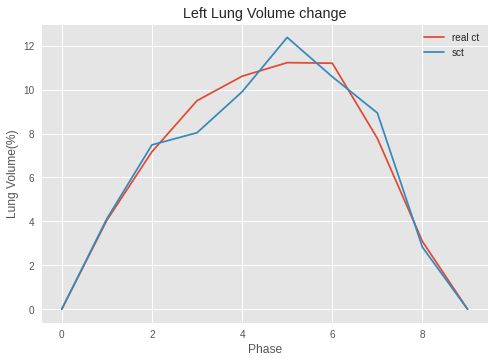

0.0


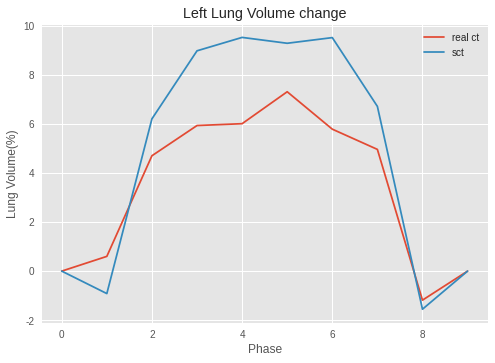

0.0


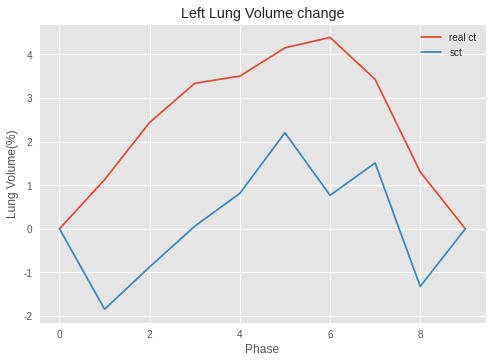

0.0


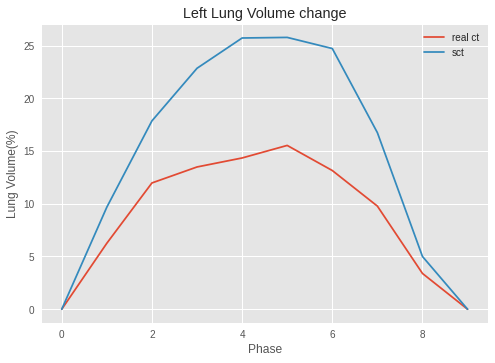

0.0


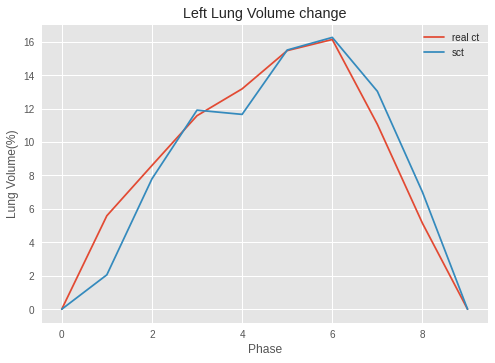

0.0


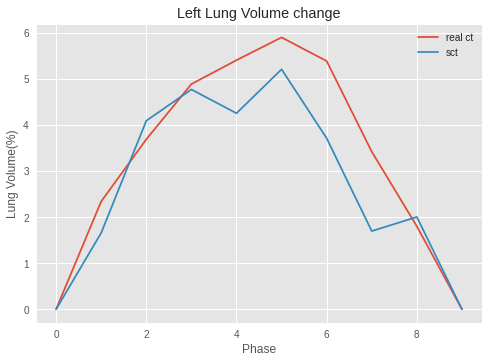

0.0


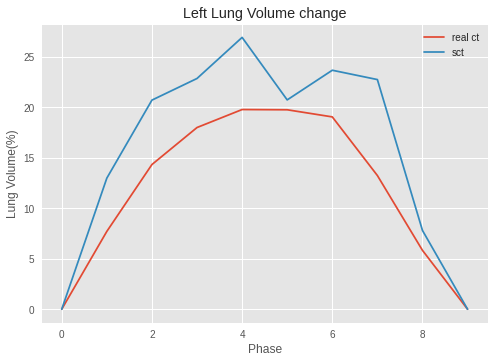

0.0


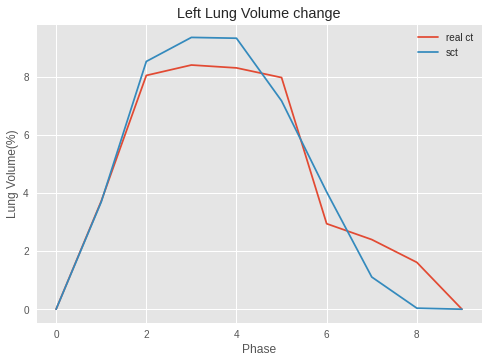

0.0


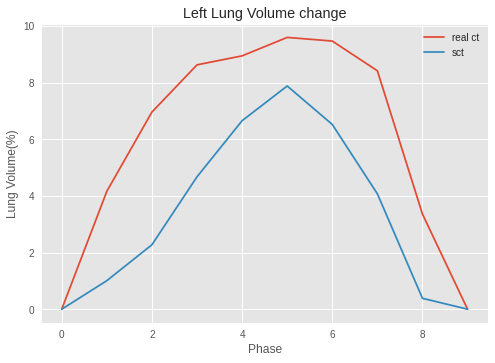

0.0


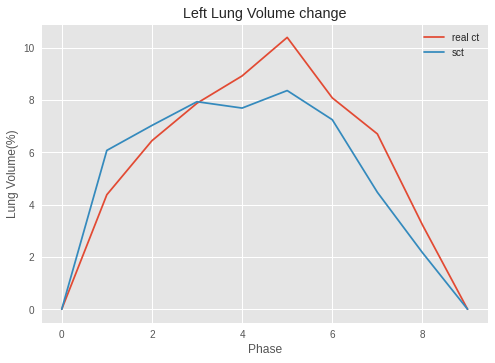

0.0


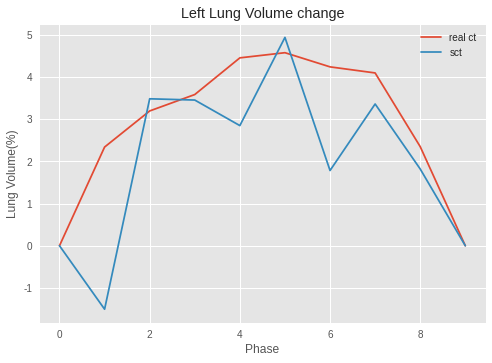

0.0


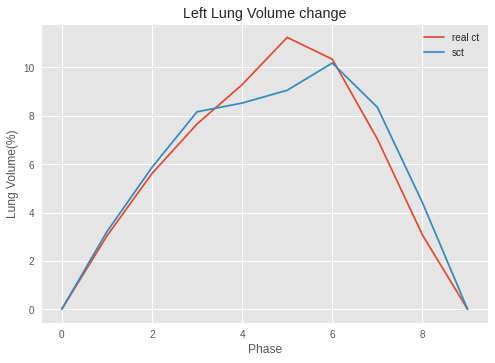

0.0


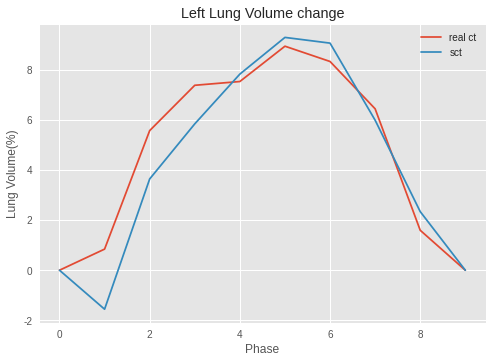

0.0


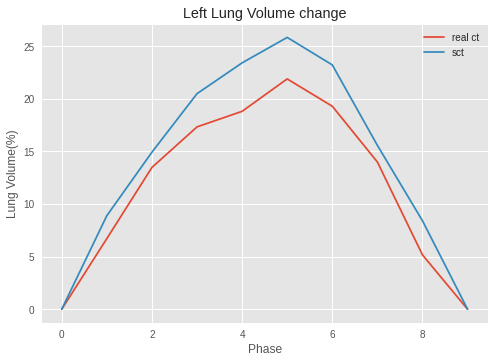

0.0


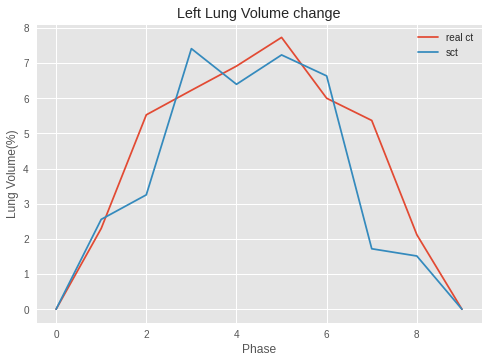

0.0


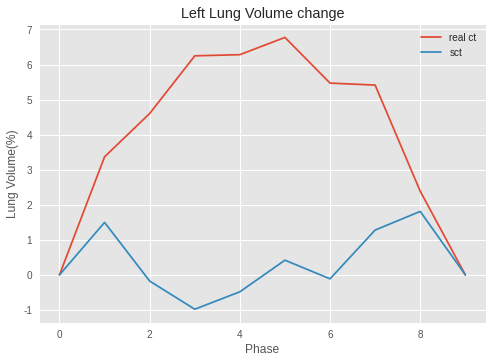

0.0


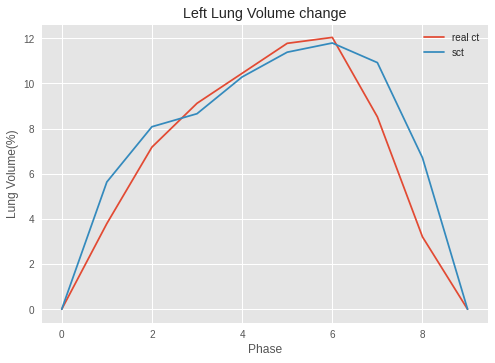

0.0


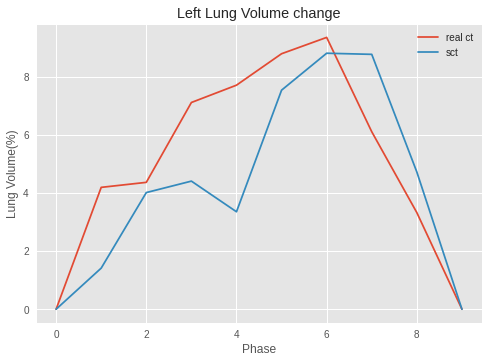

0.0


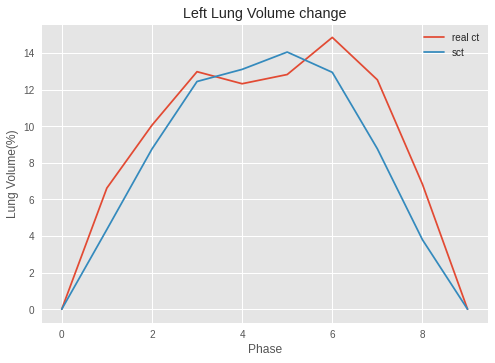

In [129]:
# left_real = np.array(result['left_real'])
# left_fake = np.array(result['left_fake'])
# right_real = np.array(result['right_real'])
# right_fake = np.array(result['right_fake'])

for real,fake in zip(left_real,left_fake):
    print(real[0])
    plotLungVolumeChange(real,fake)
